# TiffVolumeDataset Testing Notebook

This notebook tests the newly created `TiffVolumeDataset` class that loads TIFF sequences into 3D volumes and splits them into overlapping sub-volumes for training/inference.

In [1]:
try:
    import pillow_heif
    from PIL import Image
    pillow_heif.register_heif_opener()
except ImportError:
    !pip install pillow-heif
    

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 70.4 MB/s  0:00:00


In [47]:
# Add the project root to Python path so we can import pyTT
import sys
from pathlib import Path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))
print(f"Added {project_root} to Python path")

Added /myhome/sdate to Python path


In [48]:
# Import required libraries
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from torch.utils.data import DataLoader
import lovely_tensors as lt
from tqdm.auto import tqdm
import time

# Import our new dataset
from sdate.datasets import TiffVolumeDataset

# Set up lovely_tensors for better tensor visualization
lt.monkey_patch()

# Set up matplotlib
plt.rcParams['figure.figsize'] = (15, 8)
plt.rcParams['image.cmap'] = 'gray'

print("✅ Libraries imported successfully!")
print("✅ TiffVolumeDataset imported from sdate.datasets")

✅ Libraries imported successfully!
✅ TiffVolumeDataset imported from sdate.datasets


## Test 1: Basic Dataset Creation and Exploration

In [49]:
# Set up the data path
from PIL import Image  # Add missing import
data_path = Path('/myhome/data/sdate/shared/compression_paper/file_3_extracted')

print(f"Testing TiffVolumeDataset with data path: {data_path}")
print(f"Data path exists: {data_path.exists()}")

# Check the final data path
if data_path.exists():
    tiff_files = sorted(list(data_path.glob('*.tif*')))
    print(f"Found {len(tiff_files)} TIFF files")
    if len(tiff_files) > 0:
        print(f"First file: {tiff_files[0].name}")
        print(f"Last file: {tiff_files[-1].name}")
else:
    print("❌ Data path still does not exist!")

Testing TiffVolumeDataset with data path: /myhome/data/sdate/shared/compression_paper/file_3_extracted
Data path exists: True
Found 751 TIFF files
First file: MI04_020001.tif
Last file: MI04_020751.tif


In [50]:
# Create a basic dataset with small parameters for quick testing
print("Creating TiffVolumeDataset with basic parameters...")

dataset_basic = TiffVolumeDataset(
    data_path=data_path,
    num_frames=128,        # Load 200 frames for quick testing
    volume_size=128,       # Small sub-volumes for fast processing
    stride=128,            # No overlap for this test
    start_offset=150,      # Start from frame 10
    normalize=True,       # Normalize to [0, 1]
    global_normalize=True,
    use_heic_compression=True,
    heic_quality=50,
    dual_channel=True  # Use only HEIC data
)

print(f"\n📊 Basic Dataset Info:")
print(f"  Full volume shape: {dataset_basic.volume.shape}")
print(f"  Sub-volume size: {dataset_basic.volume_size}")
print(f"  Stride: {dataset_basic.stride}")
print(f"  Number of sub-volumes: {len(dataset_basic)}")
print(f"  Global value range: [{dataset_basic.global_min:.2f}, {dataset_basic.global_max:.2f}]")
print(f"  Volume value range: [{dataset_basic.volume.min():.4f}, {dataset_basic.volume.max():.4f}]")

Creating TiffVolumeDataset with basic parameters...
Loading 128 TIFF frames from /myhome/data/sdate/shared/compression_paper/file_3_extracted
HEIC compression enabled (quality=50, dual_channel=True)
  Loading frames 150 to 277 (128 files)


Loading TIFF files:   0%|          | 0/128 [00:00<?, ?files/s]

Loading TIFF files: 100%|██████████| 128/128 [00:00<00:00, 312.83files/s]


  Creating 128 HEIC compressed files...


Loading HEIC files: 100%|██████████| 128/128 [00:01<00:00, 87.54files/s]


  Created dual-channel volume: TIFF + HEIC
  Volume loaded: shape=torch.Size([128, 2, 1900, 1008]), dtype=torch.float32
  Value range: [0.00, 2928.00]
  Sub-volumes per dimension: D=1, H=15, W=8
Created TiffVolumeDataset:
  Volume shape: torch.Size([128, 2, 1900, 1008])
  Sub-volume size: 128x128x128
  Stride: 128
  Number of sub-volumes: 120
  Dataset length: 120

📊 Basic Dataset Info:
  Full volume shape: torch.Size([128, 2, 1900, 1008])
  Sub-volume size: 128
  Stride: 128
  Number of sub-volumes: 120
  Global value range: [0.00, 2928.00]
  Volume value range: [0.0000, 2928.0000]


In [56]:
# Test accessing individual sub-volumes
print("Testing sub-volume access...")

# Get first sub-volume
sub_volume_0, coors_0 = dataset_basic[0]
print(f"Sub-volume 0 shape: {sub_volume_0.shape}")
print(f"Sub-volume 0 range: [{sub_volume_0.min():.4f}, {sub_volume_0.max():.4f}]")

# Get info about this sub-volume
info_0 = dataset_basic.get_volume_info(0)
print(f"\nSub-volume 0 info:")
for key, value in info_0.items():
    print(f"  {key}: {value}")

# Test another sub-volume
if len(dataset_basic) > 1:
    sub_volume_1, coors_1 = dataset_basic[1]
    info_1 = dataset_basic.get_volume_info(1)
    print(f"\nSub-volume 1 position: {info_1['position']}")
    print(f"Sub-volume 1 shape: {sub_volume_1.shape}")
coors_0, coors_1

Testing sub-volume access...
Sub-volume 0 shape: torch.Size([2, 128, 128, 128])
Sub-volume 0 range: [0.0181, 0.3979]

Sub-volume 0 info:
  index: 0
  position: (0, 0, 0)
  end_position: (128, 128, 128)
  shape: (128, 128, 128)
  full_volume_shape: (128, 2, 1900, 1008)

Sub-volume 1 position: (0, 0, 128)
Sub-volume 1 shape: torch.Size([2, 128, 128, 128])


(tensor[3] i64 all_zeros [0, 0, 0],
 tensor[3] i64 x∈[0, 128] μ=42.667 σ=73.901 [0, 0, 128])

## Test 3: PyTorch DataLoader Integration

In [57]:
# Test with PyTorch DataLoader
print("Testing TiffVolumeDataset with PyTorch DataLoader...")

# Create DataLoader
batch_size = 4
loader = DataLoader(
    dataset_basic,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0  # Set to 0 for testing, increase for real training
)

print(f"\n📦 DataLoader Info:")
print(f"  Batch size: {batch_size}")
print(f"  Total batches: {len(loader)}")
print(f"  Total samples: {len(dataset_basic)}")

# Test loading a few batches
print("\nTesting batch loading...")
start_time = time.time()

for batch_idx, (batch, coors) in enumerate(loader):
    print(f"Batch {batch_idx + 1}: shape={batch.shape}, dtype={batch.dtype}")
    print(f"  Min: {batch.min():.4f}, Max: {batch.max():.4f}, Mean: {batch.mean():.4f}")
    
    if batch_idx >= 2:  # Just test first 3 batches
        break

loading_time = time.time() - start_time
print(f"\nLoading time for 3 batches: {loading_time:.3f} seconds")
coors

Testing TiffVolumeDataset with PyTorch DataLoader...

📦 DataLoader Info:
  Batch size: 4
  Total batches: 30
  Total samples: 120

Testing batch loading...
Batch 1: shape=torch.Size([4, 2, 128, 128, 128]), dtype=torch.float32
  Min: 0.0024, Max: 0.9180, Mean: 0.2192
Batch 2: shape=torch.Size([4, 2, 128, 128, 128]), dtype=torch.float32
  Min: 0.0041, Max: 0.5277, Mean: 0.1833
Batch 3: shape=torch.Size([4, 2, 128, 128, 128]), dtype=torch.float32
  Min: 0.0089, Max: 0.5249, Mean: 0.1809

Loading time for 3 batches: 0.895 seconds


tensor[4, 3] i64 n=12 x∈[0, 1536] μ=512.000 σ=636.500

## Test 6: Visualization

Creating visualizations...


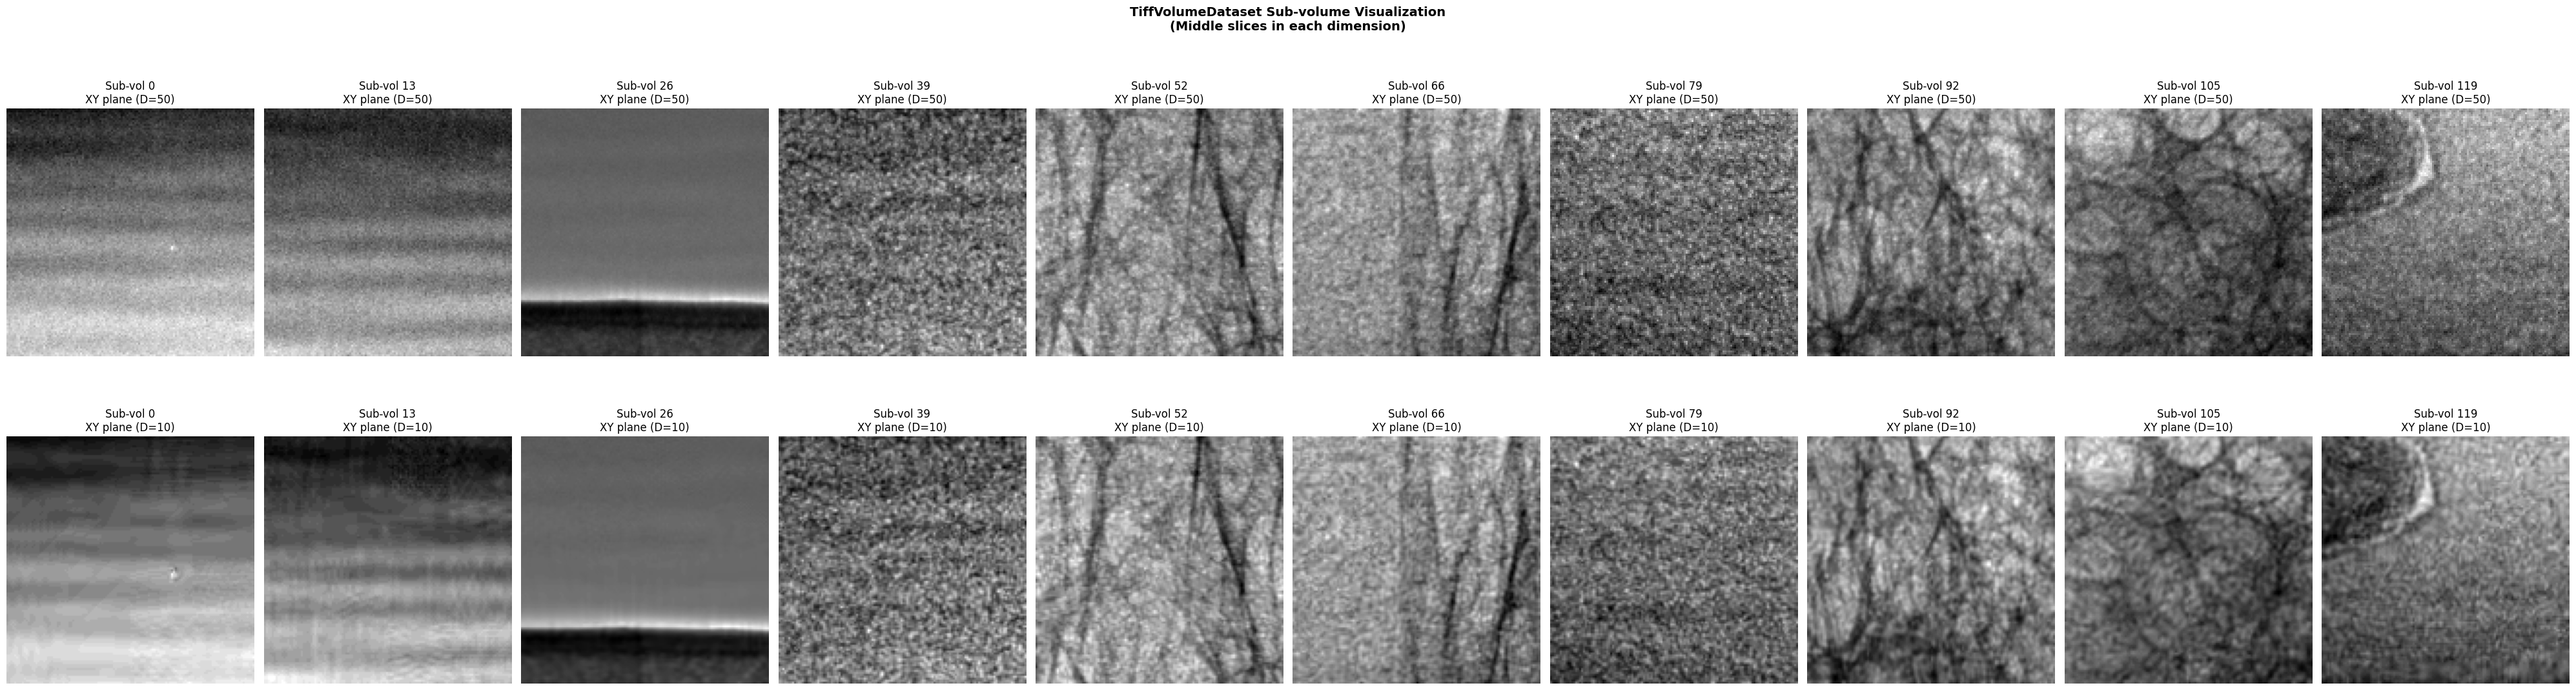

Visualized 10 sub-volumes showing middle slices in each dimension


In [62]:
# Visualize some sub-volumes
print("Creating visualizations...")

# Select a few sub-volumes to visualize
vis_indices = torch.linspace(0, len(dataset_basic)-1, steps=10).long().tolist()
vis_indices = [idx for idx in vis_indices if idx < len(dataset_basic)]

fig, axes = plt.subplots(2, len(vis_indices), figsize=(4*len(vis_indices), 12))
if len(vis_indices) == 1:
    axes = axes.reshape(-1, 1)

fig.suptitle('TiffVolumeDataset Sub-volume Visualization\n(Middle slices in each dimension)', 
             fontsize=14, fontweight='bold')
for i, idx in enumerate(vis_indices):
    sub_vol, coors = dataset_basic[idx]
    info = dataset_basic.get_volume_info(idx)

    # Get middle slices
    mid_d = 50
    
    # XY plane (depth slice)
    axes[0, i].imshow(sub_vol[0, mid_d].numpy(), cmap='gray')
    axes[0, i].set_title(f'Sub-vol {idx}\nXY plane (D={mid_d})')
    axes[0, i].axis('off')
    
    # XY plane (depth slice)
    axes[1, i].imshow(sub_vol[1, mid_d].numpy(), cmap='gray')
    axes[1, i].set_title(f'Sub-vol {idx}\nXY plane (D={10})')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

print(f"Visualized {len(vis_indices)} sub-volumes showing middle slices in each dimension")

In [63]:
# Add the project root to Python path so we can import pyTT

sys.path.insert(0, str(project_root.parent) + "/chip-project")
print(f"Added {str(project_root.parent) + '/chip-project'} to Python path")
from chip.utils.metrics import PSNR

Added /myhome/chip-project to Python path


In [103]:
sub_vol, _ = dataset_basic[92]
sub_vol[1] = sub_vol[0].min() + sub_vol[0].max() * (sub_vol[1] - sub_vol[1].min()) / sub_vol[1].max()

tensor 25.716

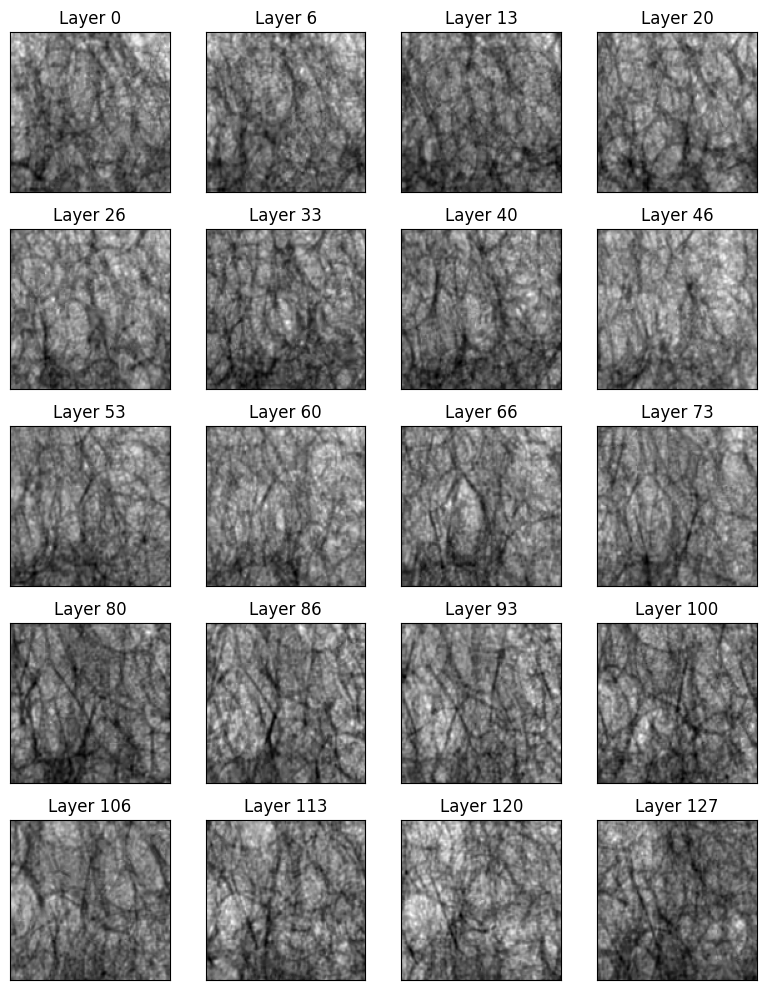

In [116]:
from chip.utils.plotting import plot_tomogram_overview
plot_tomogram_overview(sub_vol[1])
PSNR(sub_vol[0], sub_vol[1])